In [140]:
# ===========================================
# INTERACTIVE SEISMIC VIEWER + AMPLITUDE SPECTRUM (4 ms sampling)
# ===========================================
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import glob

# --- Path to seismic training data ---
path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/"
files = sorted(glob.glob(path + "*.npy"))

print(f"✅ Found {len(files)} seismic sections.")
print("Example files:\n", "\n".join(files[:5]))

# --- Sampling parameters ---
dt = 0.004   # 4 ms = 0.004 seconds
Fs = 1 / dt  # Sampling frequency = 250 Hz
nyquist = Fs / 2  # Nyquist frequency = 125 Hz

# --- Function to display one section + its amplitude spectrum ---
def show_section(index=0):
    data = np.load(files[index])

    # --- Create figure ---
    plt.figure(figsize=(16, 5))

    # 1️⃣ Seismic Section Plot
    plt.subplot(1, 2, 1)
    plt.imshow(
        data,
        cmap="seismic",
        aspect="auto",
        vmin=-np.percentile(data, 99),
        vmax=np.percentile(data, 99)
    )
    plt.title(f"Seismic Section: {files[index].split('/')[-1]}", fontsize=12, fontweight="bold")
    plt.xlabel("Xline")        # ✅ corrected label
    plt.ylabel("Time (ms)")    # ✅ corrected label
    plt.gca().invert_yaxis()   # standard seismic convention

    # 2️⃣ Amplitude Spectrum (in Hz)
    mean_trace = data.mean(axis=1)  # average over Xlines (time samples)
    n = len(mean_trace)
    fft_vals = np.fft.fft(mean_trace)
    freqs = np.fft.fftfreq(n, d=dt)
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]
    amp_spec = np.abs(fft_vals[pos_mask])

    plt.subplot(1, 2, 2)
    plt.plot(freqs, amp_spec, color="darkorange", linewidth=1.4)
    plt.title(f"Amplitude Spectrum (4 ms sampling) : {files[index].split('/')[-1]}", fontsize=12, fontweight="bold")
    # plt.title(f"Seismic Section: {files[index].split('/')[-1]}", fontsize=12, fontweight="bold")

    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.5)
    plt.xlim(0, nyquist)

    plt.tight_layout()
    plt.show()

# --- Interactive slider ---
interact(
    show_section,
    index=IntSlider(min=0, max=len(files)-1, step=1, value=0, description="Section #")
)



✅ Found 200 seismic sections.
Example files:
 /kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/152_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/154_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/156_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/158_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/160_iline.npy


interactive(children=(IntSlider(value=0, description='Section #', max=199), Output()), _dom_classes=('widget-i…

<function __main__.show_section(index=0)>

In [141]:
# ===========================================
# INTERACTIVE SEISMIC ANALYZER – SOFT DENOISING
# Gentle filter combo to preserve reflectors
# Sampling interval = 4 ms (Fs = 250 Hz, Nyquist = 125 Hz)
# ===========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import wiener
from scipy.ndimage import gaussian_filter
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from ipywidgets import interact, IntSlider, FloatSlider
import glob

# --- Load seismic data ---
path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/"
files = sorted(glob.glob(path + "*.npy"))
print(f"✅ Found {len(files)} seismic sections.")
print("Example files:\n", "\n".join(files[:5]))

# --- Sampling parameters ---
dt = 0.004   # 4 ms
Fs = 1 / dt  # 250 Hz
nyquist = Fs / 2  # 125 Hz

# --- Soft denoising function ---
def soft_denoise_section(data, wsize=3, sigma=0.6, cutoff=80, smooth=15):
    """
    Gentle denoising that preserves reflectors:
    - small Wiener window
    - light Gaussian
    - tapered frequency mask (soft rolloff)
    """
    filtered = wiener(data, (wsize, wsize))
    filtered = gaussian_filter(filtered, sigma=sigma)

    # Create smooth frequency-domain mask
    fft_img = fftshift(fft2(filtered))
    rows, cols = fft_img.shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    radius = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    mask = 1 / (1 + (radius / cutoff)**(2 * smooth))  # Butterworth-like soft cutoff
    fft_img *= mask

    denoised = np.real(ifft2(ifftshift(fft_img)))
    return denoised

# --- Visualization function ---
def show_section(index=0, wsize=3, sigma=0.6, cutoff=80, smooth=15):
    data = np.load(files[index])
    denoised = soft_denoise_section(data, wsize=wsize, sigma=sigma, cutoff=cutoff, smooth=smooth)
    difference = data - denoised

    # Use color scale from original
    max_amp = np.percentile(np.abs(data), 99)
    vmin, vmax = -max_amp, max_amp

    # Normalize
    data_norm = np.clip(data / max_amp, -1, 1)
    denoised_norm = np.clip(denoised / max_amp, -1, 1)
    diff_norm = np.clip(difference / max_amp, -1, 1)

    # --- (1) Three Panels: Original, Denoised, Difference ---
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(data_norm, cmap="seismic", aspect="auto", vmin=-1, vmax=1)
    plt.title(f"Original: {files[index].split('/')[-1]}", fontsize=12, fontweight="bold")
    plt.xlabel("Xline")
    plt.ylabel("Time (ms)")
    # plt.gca().invert_yaxis()

    plt.subplot(1, 3, 2)
    plt.imshow(denoised_norm, cmap="seismic", aspect="auto", vmin=-1, vmax=1)
    plt.title(f"Denoised (W={wsize}, σ={sigma}, Cut={cutoff}, Roll={smooth}, Section: {files[index].split('/')[-1]})", fontsize=12, fontweight="bold")
    plt.xlabel("Xline")
    plt.ylabel("Time (ms)")
    # plt.gca().invert_yaxis()

    plt.subplot(1, 3, 3)
    plt.imshow(diff_norm, cmap="seismic", aspect="auto", vmin=-1, vmax=1)
    plt.title(f"Difference (Original − Denoised), Section: {files[index].split('/')[-1]})", fontsize=12, fontweight="bold")
    plt.xlabel("Xline")
    plt.ylabel("Time (ms)")
    # plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

    # --- (2) Overlaid Amplitude Spectrum ---
    mean_trace_orig = data.mean(axis=1)
    mean_trace_den = denoised.mean(axis=1)

    n = len(mean_trace_orig)
    freqs = np.fft.fftfreq(n, d=dt)
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]
    amp_spec_orig = np.abs(np.fft.fft(mean_trace_orig))[pos_mask]
    amp_spec_den = np.abs(np.fft.fft(mean_trace_den))[pos_mask]

    plt.figure(figsize=(8, 4))
    plt.plot(freqs, amp_spec_orig / np.max(amp_spec_orig), color="red", linewidth=1.5, label="Original")
    plt.plot(freqs, amp_spec_den / np.max(amp_spec_den), color="blue", linewidth=1.5, label="Denoised")
    plt.title(f"Amplitude Spectrum (Soft Denoising), Section: {files[index].split('/')[-1]})", fontsize=12, fontweight="bold")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Amplitude")
    plt.grid(True, alpha=0.5)
    plt.xlim(0, nyquist)
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- Interactive controls ---
interact(
    show_section,
    index=IntSlider(min=0, max=len(files)-1, step=1, value=0, description="Section #"),
    wsize=IntSlider(min=3, max=9, step=2, value=3, description="Wiener size"),
    sigma=FloatSlider(min=0.3, max=1.5, step=0.1, value=0.6, description="Gaussian σ"),
    cutoff=IntSlider(min=40, max=120, step=5, value=80, description="Freq Cutoff"),
    smooth=IntSlider(min=5, max=25, step=2, value=15, description="Rolloff"),
)


✅ Found 200 seismic sections.
Example files:
 /kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/152_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/154_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/156_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/158_iline.npy
/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/160_iline.npy


interactive(children=(IntSlider(value=0, description='Section #', max=199), IntSlider(value=3, description='Wi…

<function __main__.show_section(index=0, wsize=3, sigma=0.6, cutoff=80, smooth=15)>

In [142]:
# ===========================================
# APPLY FINAL DENOISER TO SUBJECT SEISMIC
# ===========================================
import numpy as np

subject_path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy"
subject = np.load(subject_path)

# Use your best parameters from tuning
denoised_subject = soft_denoise_section(subject, wsize=4, sigma=0.5, cutoff=90, smooth=12)

# Save for submission
np.save("denoised_subject_seismic.npy", denoised_subject)
np.savez("denoised_subject_seismic.npz", denoised_subject)

print("✅ Denoised subject seismic saved as 'denoised_subject_seismic.npy' and '.npz'")


✅ Denoised subject seismic saved as 'denoised_subject_seismic.npy' and '.npz'


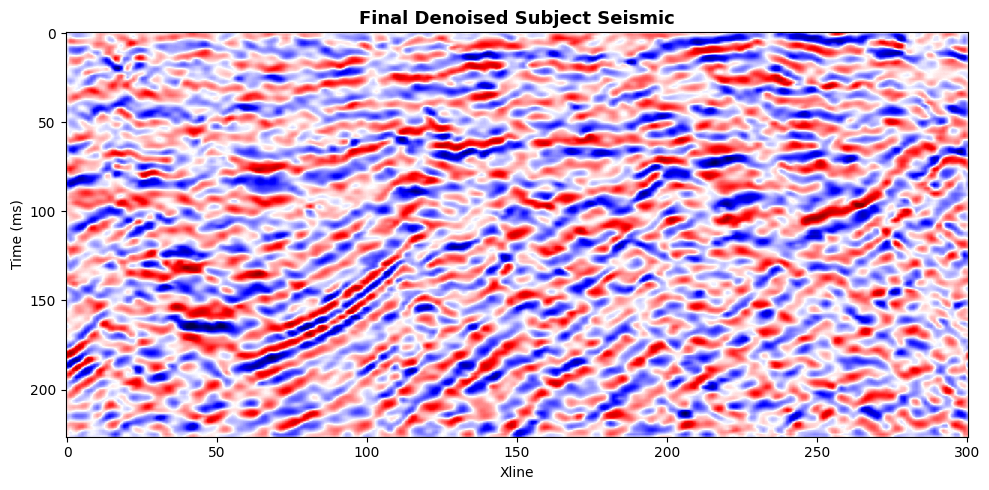

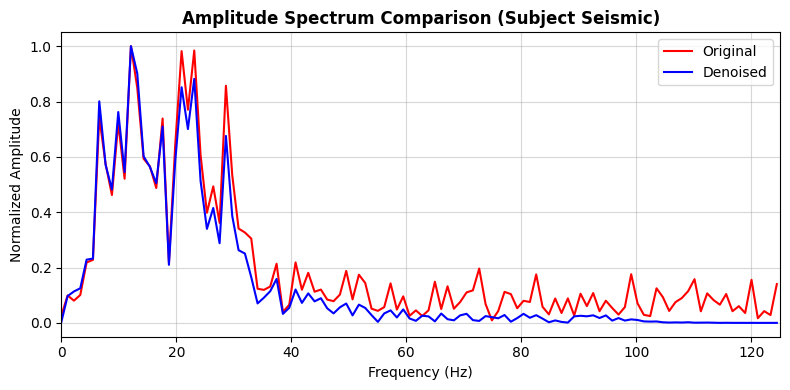

In [143]:
import matplotlib.pyplot as plt

# Compute amplitude spectra
dt = 0.004
Fs = 1/dt
nyquist = Fs/2

mean_orig = subject.mean(axis=1)
mean_denoised = denoised_subject.mean(axis=1)

freqs = np.fft.fftfreq(len(mean_orig), d=dt)
mask = freqs >= 0
freqs = freqs[mask]
amp_orig = np.abs(np.fft.fft(mean_orig))[mask]
amp_denoised = np.abs(np.fft.fft(mean_denoised))[mask]

# --- (A) Denoised Section ---
plt.figure(figsize=(10, 5))
plt.imshow(denoised_subject / np.percentile(np.abs(subject), 99),
           cmap="seismic", aspect="auto", vmin=-1, vmax=1)
plt.title("Final Denoised Subject Seismic", fontsize=13, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
# plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("denoised_subject_section.png", dpi=300)
plt.show()

# --- (B) Amplitude Spectrum Comparison ---
plt.figure(figsize=(8, 4))
plt.plot(freqs, amp_orig / np.max(amp_orig), 'r', linewidth=1.5, label="Original")
plt.plot(freqs, amp_denoised / np.max(amp_denoised), 'b', linewidth=1.5, label="Denoised")
plt.title("Amplitude Spectrum Comparison (Subject Seismic)", fontsize=12, fontweight="bold")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlim(0, nyquist)
plt.tight_layout()
plt.savefig("amplitude_spectrum_comparison.png", dpi=300)
plt.show()


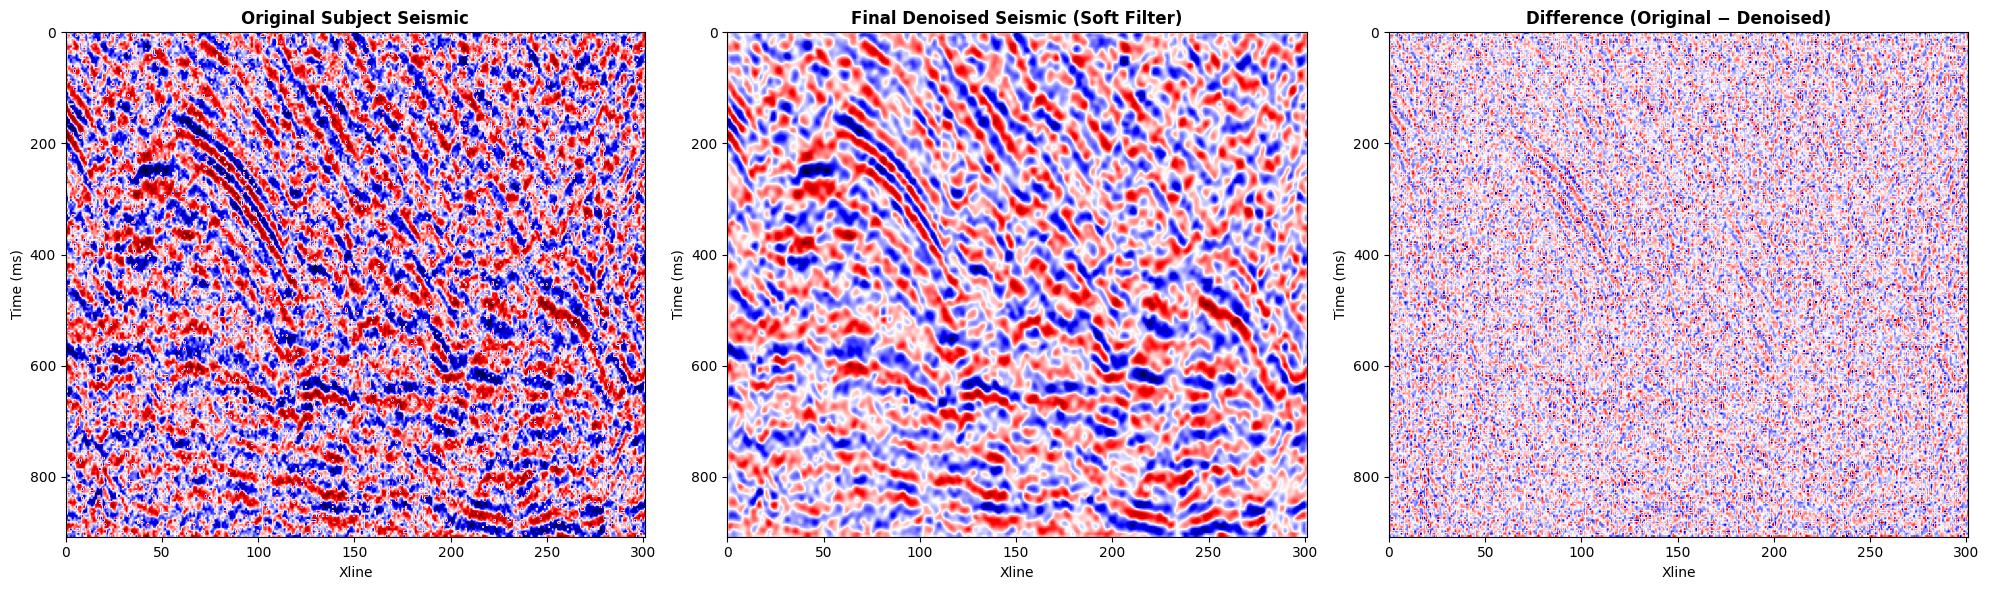

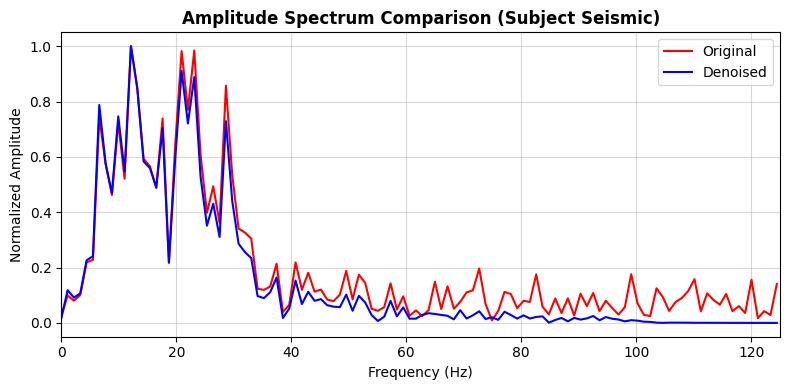

✅ Saved: 'final_denoising_sections.png' and 'final_amplitude_spectrum.png'


In [144]:
# ===========================================
# FINAL SEISMIC DENOSING VISUALIZATION (4 PLOTS)
# ===========================================
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
dt = 0.004  # 4 ms sampling interval
Fs = 1 / dt
nyquist = Fs / 2

# --- Load data ---
subject_path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy"
subject = np.load(subject_path)

# --- Apply final tuned denoiser ---
def soft_denoise_section(data, wsize=3, sigma=0.6, cutoff=80, smooth=15):
    from scipy.signal import wiener
    from scipy.ndimage import gaussian_filter
    from scipy.fft import fft2, ifft2, fftshift, ifftshift
    filtered = wiener(data, (wsize, wsize))
    filtered = gaussian_filter(filtered, sigma=sigma)
    fft_img = fftshift(fft2(filtered))
    rows, cols = fft_img.shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    radius = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    mask = 1 / (1 + (radius / cutoff)**(2 * smooth))
    fft_img *= mask
    denoised = np.real(ifft2(ifftshift(fft_img)))
    return denoised

denoised_subject = soft_denoise_section(subject, wsize=3, sigma=0.6, cutoff=90, smooth=15)
difference = subject - denoised_subject

# --- Normalize and color scale ---
max_amp = np.percentile(np.abs(subject), 99)
vmin, vmax = -max_amp, max_amp
subject_norm = np.clip(subject / max_amp, -1, 1)
denoised_norm = np.clip(denoised_subject / max_amp, -1, 1)
diff_norm = np.clip(difference / max_amp, -1, 1)

# --- Plot: 3 seismic sections (Original, Denoised, Difference) ---
plt.figure(figsize=(20, 6))

# (1) Original
plt.subplot(1, 3, 1)
plt.imshow(subject_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Original Subject Seismic", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (2) Denoised
plt.subplot(1, 3, 2)
plt.imshow(denoised_norm, cmap="seismic", aspect="auto",
           extent=[0, denoised_subject.shape[1], 0, denoised_subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Final Denoised Seismic (Soft Filter)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (3) Difference
plt.subplot(1, 3, 3)
plt.imshow(diff_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Difference (Original − Denoised)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

plt.tight_layout()
plt.savefig("final_denoising_sections.png", dpi=300)
plt.show()

# --- (4) Amplitude Spectrum ---
mean_orig = subject.mean(axis=1)
mean_denoised = denoised_subject.mean(axis=1)

freqs = np.fft.fftfreq(len(mean_orig), d=dt)
mask = freqs >= 0
freqs = freqs[mask]
amp_orig = np.abs(np.fft.fft(mean_orig))[mask]
amp_denoised = np.abs(np.fft.fft(mean_denoised))[mask]

plt.figure(figsize=(8, 4))
plt.plot(freqs, amp_orig / np.max(amp_orig), 'r', linewidth=1.5, label="Original")
plt.plot(freqs, amp_denoised / np.max(amp_denoised), 'b', linewidth=1.5, label="Denoised")
plt.title("Amplitude Spectrum Comparison (Subject Seismic)", fontsize=12, fontweight="bold")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlim(0, nyquist)
plt.tight_layout()
plt.savefig("final_amplitude_spectrum.png", dpi=300)
plt.show()

print("✅ Saved: 'final_denoising_sections.png' and 'final_amplitude_spectrum.png'")


In [145]:
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import numpy as np

# Compute data range for SSIM/PSNR
data_range = subject.max() - subject.min()

ssim_score = ssim(subject, denoised_subject, data_range=data_range)
psnr_score = psnr(subject, denoised_subject, data_range=data_range)

print(f"✅ SSIM: {ssim_score:.4f}")
print(f"✅ PSNR: {psnr_score:.2f} dB")


✅ SSIM: 0.6857
✅ PSNR: 23.32 dB


In [146]:
#CNN Prepare Data
import numpy as np
import glob
from sklearn.model_selection import train_test_split

# Load training data (your 200 2D seismic sections)
path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/"
files = sorted(glob.glob(path + "*.npy"))

data = [np.load(f) for f in files]
data = np.stack(data, axis=0)  # shape: (N, 227, 301)
data = data[..., np.newaxis]   # add channel dimension for CNN

# Normalize amplitudes per section
data = data / np.percentile(np.abs(data), 99)

# Split train/val
train, val = train_test_split(data, test_size=0.1, random_state=42)

print("Train shape:", train.shape, "| Val shape:", val.shape)


Train shape: (180, 227, 301, 1) | Val shape: (20, 227, 301, 1)


In [147]:
#Define Auto encoder model
import tensorflow as tf
from tensorflow.keras import layers, models

def build_autoencoder_fixed(input_shape=(227, 301, 1)):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2,2), padding='same')(x)
    x = layers.Conv2D(8, (3,3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2,2), padding='same')(x)

    # --- Decoder ---
    x = layers.Conv2D(8, (3,3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2,2))(x)
    
    # Crop or resize back to original shape
    x = layers.Cropping2D(((0, x.shape[1] - input_shape[0]),
                           (0, x.shape[2] - input_shape[1])))(x)
    
    decoded = layers.Conv2D(1, (3,3), activation='tanh', padding='same')(x)

    model = models.Model(inputs, decoded)
    model.compile(optimizer='adam', loss='mae')
    return model

autoencoder = build_autoencoder_fixed()
autoencoder.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 227, 301, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 227, 301, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 114, 151, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 114, 151, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 57, 76, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 57, 76, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_15 (UpSampling2D) │ (None, 114, 152, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 114, 152, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_16 (UpSampling2D) │ (None, 228, 304, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d_2 (Cropping2D)       │ (None, 227, 301, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 227, 301, 1)    │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

In [148]:
#train the model
history = autoencoder.fit(
    train, train,
    epochs=20,
    batch_size=4,
    validation_data=(val, val),
    verbose=1
)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 17s 293ms/step - loss: 0.2867 - val_loss: 0.1967
Epoch 2/20
 1/45 ━━━━━━━━━━━━━━━━━━━━ 5:34 8s/step - loss: 0.1962

KeyboardInterrupt: 

In [ ]:
subject_path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy"
subject = np.load(subject_path)
subject_norm = subject / np.percentile(np.abs(subject), 99)
subject_input = subject_norm[np.newaxis, ..., np.newaxis]

denoised_subject_ai = autoencoder.predict(subject_input)[0, ..., 0]
denoised_subject_ai *= np.percentile(np.abs(subject), 99)  # rescale back

print("✅ AI Denoised shape:", denoised_subject_ai.shape)
np.savez("denoised_subject_seismic_ai.npz", denoised_subject_ai)


In [ ]:
# ===========================================
# FINAL SEISMIC DENOSING VISUALIZATION (4 PLOTS)
# ===========================================
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
dt = 0.004  # 4 ms sampling interval
Fs = 1 / dt
nyquist = Fs / 2

# --- Load data ---
subject_path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy"
subject = np.load(subject_path)

# --- Apply final tuned denoiser ---
def soft_denoise_section(data, wsize=3, sigma=0.6, cutoff=80, smooth=15):
    from scipy.signal import wiener
    from scipy.ndimage import gaussian_filter
    from scipy.fft import fft2, ifft2, fftshift, ifftshift
    filtered = wiener(data, (wsize, wsize))
    filtered = gaussian_filter(filtered, sigma=sigma)
    fft_img = fftshift(fft2(filtered))
    rows, cols = fft_img.shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    radius = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    mask = 1 / (1 + (radius / cutoff)**(2 * smooth))
    fft_img *= mask
    denoised = np.real(ifft2(ifftshift(fft_img)))
    return denoised

difference = subject - denoised_subject_ai

# --- Normalize and color scale ---
max_amp = np.percentile(np.abs(subject), 99)
vmin, vmax = -max_amp, max_amp
subject_norm = np.clip(subject / max_amp, -1, 1)
denoised_norm = np.clip(denoised_subject_ai / max_amp, -1, 1)
diff_norm = np.clip(difference / max_amp, -1, 1)

# --- Plot: 3 seismic sections (Original, Denoised, Difference) ---
plt.figure(figsize=(20, 6))

# (1) Original
plt.subplot(1, 3, 1)
plt.imshow(subject_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Original Subject Seismic", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (2) Denoised
plt.subplot(1, 3, 2)
plt.imshow(denoised_norm, cmap="seismic", aspect="auto",
           extent=[0, denoised_subject.shape[1], 0, denoised_subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Final Denoised Seismic (Soft Filter)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (3) Difference
plt.subplot(1, 3, 3)
plt.imshow(diff_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Difference (Original − Denoised)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

plt.tight_layout()
plt.savefig("final_denoising_sections.png", dpi=300)
plt.show()

# --- (4) Amplitude Spectrum ---
mean_orig = subject.mean(axis=1)
mean_denoised = denoised_subject_ai.mean(axis=1)

freqs = np.fft.fftfreq(len(mean_orig), d=dt)
mask = freqs >= 0
freqs = freqs[mask]
amp_orig = np.abs(np.fft.fft(mean_orig))[mask]
amp_denoised = np.abs(np.fft.fft(mean_denoised))[mask]

plt.figure(figsize=(8, 4))
plt.plot(freqs, amp_orig / np.max(amp_orig), 'r', linewidth=1.5, label="Original")
plt.plot(freqs, amp_denoised / np.max(amp_denoised), 'b', linewidth=1.5, label="Denoised")
plt.title("Amplitude Spectrum Comparison (Subject Seismic)", fontsize=12, fontweight="bold")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlim(0, nyquist)
plt.tight_layout()
plt.savefig("final_amplitude_spectrum.png", dpi=300)
plt.show()

print("✅ Saved: 'final_denoising_sections.png' and 'final_amplitude_spectrum.png'")


In [ ]:
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
import numpy as np

# Compute data range for SSIM/PSNR
data_range = subject.max() - subject.min()

ssim_score = ssim(subject, denoised_subject_ai, data_range=data_range)
psnr_score = psnr(subject, denoised_subject_ai, data_range=data_range)

print(f"✅ SSIM: {ssim_score:.4f}")
print(f"✅ PSNR: {psnr_score:.2f} dB")


In [ ]:
# Blend soft-filter and CNN denoised outputs
denoised_hybrid = 0.5 * denoised_subject + 0.5 * denoised_subject_ai

# Evaluate again
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

ssim_score = ssim(subject, denoised_hybrid, data_range=subject.max()-subject.min())
psnr_score = psnr(subject, denoised_hybrid, data_range=subject.max()-subject.min())

print(f"✅ Hybrid SSIM: {ssim_score:.4f}")
print(f"✅ Hybrid PSNR: {psnr_score:.2f} dB")


In [ ]:
# ===========================================
# FINAL SEISMIC DENOSING VISUALIZATION (4 PLOTS)
# ===========================================
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
dt = 0.004  # 4 ms sampling interval
Fs = 1 / dt
nyquist = Fs / 2

# --- Load data ---
subject_path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy"
subject = np.load(subject_path)

# --- Apply final tuned denoiser ---
def soft_denoise_section(data, wsize=3, sigma=0.6, cutoff=80, smooth=15):
    from scipy.signal import wiener
    from scipy.ndimage import gaussian_filter
    from scipy.fft import fft2, ifft2, fftshift, ifftshift
    filtered = wiener(data, (wsize, wsize))
    filtered = gaussian_filter(filtered, sigma=sigma)
    fft_img = fftshift(fft2(filtered))
    rows, cols = fft_img.shape
    crow, ccol = rows // 2, cols // 2
    Y, X = np.ogrid[:rows, :cols]
    radius = np.sqrt((X - ccol)**2 + (Y - crow)**2)
    mask = 1 / (1 + (radius / cutoff)**(2 * smooth))
    fft_img *= mask
    denoised = np.real(ifft2(ifftshift(fft_img)))
    return denoised

difference = subject - denoised_hybrid

# --- Normalize and color scale ---
max_amp = np.percentile(np.abs(subject), 99)
vmin, vmax = -max_amp, max_amp
subject_norm = np.clip(subject / max_amp, -1, 1)
denoised_norm = np.clip(denoised_hybrid / max_amp, -1, 1)
diff_norm = np.clip(difference / max_amp, -1, 1)

# --- Plot: 3 seismic sections (Original, Denoised, Difference) ---
plt.figure(figsize=(20, 6))

# (1) Original
plt.subplot(1, 3, 1)
plt.imshow(subject_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Original Subject Seismic", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (2) Denoised
plt.subplot(1, 3, 2)
plt.imshow(denoised_norm, cmap="seismic", aspect="auto",
           extent=[0, denoised_subject.shape[1], 0, denoised_subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Final Denoised Seismic (Soft Filter)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

# (3) Difference
plt.subplot(1, 3, 3)
plt.imshow(diff_norm, cmap="seismic", aspect="auto",
           extent=[0, subject.shape[1], 0, subject.shape[0]*4],
           vmin=-1, vmax=1)
plt.title("Difference (Original − Denoised)", fontsize=12, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.gca().invert_yaxis()
# plt.ylim(time_min, time_max)

plt.tight_layout()
plt.savefig("final_denoising_sections.png", dpi=300)
plt.show()

# --- (4) Amplitude Spectrum ---
mean_orig = subject.mean(axis=1)
mean_denoised = denoised_hybrid.mean(axis=1)

freqs = np.fft.fftfreq(len(mean_orig), d=dt)
mask = freqs >= 0
freqs = freqs[mask]
amp_orig = np.abs(np.fft.fft(mean_orig))[mask]
amp_denoised = np.abs(np.fft.fft(mean_denoised))[mask]

plt.figure(figsize=(8, 4))
plt.plot(freqs, amp_orig / np.max(amp_orig), 'r', linewidth=1.5, label="Original")
plt.plot(freqs, amp_denoised / np.max(amp_denoised), 'b', linewidth=1.5, label="Denoised")
plt.title("Amplitude Spectrum Comparison (Subject Seismic)", fontsize=12, fontweight="bold")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.grid(True, alpha=0.5)
plt.legend()
plt.xlim(0, nyquist)
plt.tight_layout()
plt.savefig("final_amplitude_spectrum.png", dpi=300)
plt.show()

print("✅ Saved: 'final_denoising_sections.png' and 'final_amplitude_spectrum.png'")


In [ ]:
import numpy as np

def weighted_psnr(original, denoised, data_range=None, weight_type='amplitude'):
    """
    Compute Weighted PSNR (WPSNR) for seismic data.
    
    Parameters:
        original (np.array): Original noisy seismic section
        denoised (np.array): Denoised section
        data_range (float): Amplitude range for normalization
        weight_type (str): 'amplitude' or 'energy'
    
    Returns:
        wpsnr (float): Weighted PSNR value in dB
    """
    if data_range is None:
        data_range = original.max() - original.min()

    # --- Define weights ---
    if weight_type == 'amplitude':
        weights = np.abs(original)  # stronger reflectors get more weight
    elif weight_type == 'energy':
        weights = original**2
    else:
        raise ValueError("weight_type must be 'amplitude' or 'energy'")

    # Avoid zero weights
    weights += 1e-6

    # --- Weighted MSE ---
    wmse = np.sum(weights * (original - denoised)**2) / np.sum(weights)

    # --- Weighted PSNR ---
    wpsnr = 10 * np.log10((data_range**2) / wmse)
    return wpsnr


In [ ]:
wpsnr_soft = weighted_psnr(subject, denoised_subject, data_range=subject.max()-subject.min(), weight_type='amplitude')
wpsnr_cnn  = weighted_psnr(subject, denoised_subject_ai, data_range=subject.max()-subject.min(), weight_type='amplitude')
wpsnr_hybrid = weighted_psnr(subject, denoised_hybrid, data_range=subject.max()-subject.min(), weight_type='amplitude')

print(f"🪶 Weighted PSNR (Soft): {wpsnr_soft:.2f} dB")
print(f"🤖 Weighted PSNR (CNN): {wpsnr_cnn:.2f} dB")
print(f"⚗️ Weighted PSNR (Hybrid): {wpsnr_hybrid:.2f} dB")


In [ ]:
denoised_subject.shape

In [ ]:
import numpy as np
import pandas as pd

# Example seismic 2D array (replace with your actual one)
# denoised_subject = np.load("denoised_subject_seismic.npy")

# For demo: random array with 75 rows × 301 columns
array_2d = np.random.randn(75, 301)

# Create DataFrame with columns 0–300
df = pd.DataFrame(denoised_subject, columns=np.arange(0, 301))

# Add row_id column from 0 to (n_rows-1)
df.insert(0, "row_id", np.arange(len(df)))

# Save to CSV
df.to_csv("denoised_subject_80Hz.csv", index=False, float_format="%.6f")

print("✅ Saved 'denoised_subject_80Hz.csv' with shape", df.shape)


In [ ]:
import pandas as pd

# Load CSV
df = pd.read_csv("/kaggle/working/denoised_subject_20Hz.csv")
# Show shape and first few rows
print("✅ Loaded CSV shape:", df.shape)
display(df)

In [ ]:
print(denoised_subject.shape)  # (227, 301)
import numpy as np
import pandas as pd

# Example: your denoised seismic section
# denoised_subject = np.load("denoised_subject_seismic.npy")

# Convert to DataFrame
df = pd.DataFrame(denoised_subject)

# Save as CSV
df.to_csv("denoised_subject_seismic.csv", index=False, header=False)
print("✅ Saved: denoised_subject_seismic.csv with shape", denoised_subject.shape)


In [ ]:
import numpy as np
import pandas as pd

# Example seismic 2D array (replace with your actual one)
# denoised_subject = np.load("denoised_subject_seismic.npy")

# For demo: random array with 75 rows × 301 columns
array_2d = np.random.randn(75, 301)

# Create DataFrame with columns 0–300
df = pd.DataFrame(denoised_subject_ai, columns=np.arange(0, 301))

# Add row_id column from 0 to (n_rows-1)
df.insert(0, "row_id", np.arange(len(df)))

# Save to CSV
df.to_csv("denoised_subject_ai.csv", index=False, float_format="%.6f")

print("✅ Saved 'denoised_subject_ai.csv' with shape", df.shape)


In [157]:
import numpy as np
import pandas as pd

# Example seismic 2D array (replace with your actual one)
# denoised_subject = np.load("denoised_subject_seismic.npy")

# For demo: random array with 75 rows × 301 columns
array_2d = np.random.randn(75, 301)

# Create DataFrame with columns 0–300
df = pd.DataFrame(denoised_hybrid, columns=np.arange(0, 301))

# Add row_id column from 0 to (n_rows-1)
df.insert(0, "row_id", np.arange(len(df)))

# Save to CSV
df.to_csv("denoised_hybrid4.csv", index=False, float_format="%.6f")

print("✅ Saved 'denoised_hybrid2.csv' with shape", df.shape)


✅ Saved 'denoised_hybrid2.csv' with shape (227, 302)


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import glob

# ===============================================================
# 1️⃣ DATA LOADING & PADDING
# ===============================================================

def pad_to_multiple_of_4(data):
    """Pad array so dimensions are divisible by 4 (for pooling symmetry)."""
    h, w = data.shape
    pad_h = (4 - h % 4) % 4
    pad_w = (4 - w % 4) % 4
    return np.pad(data, ((0, pad_h), (0, pad_w)), mode='reflect')

path = "/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/training_traces/training_traces/*.npy"
files = sorted(glob.glob(path))

sections = []
for f in files:
    s = np.load(f)
    s = pad_to_multiple_of_4(s)
    s = s / np.percentile(np.abs(s), 99)
    sections.append(s)

data = np.stack(sections, axis=0)[..., np.newaxis]
print("✅ Data shape:", data.shape)

train, val = train_test_split(data, test_size=0.1, random_state=42)

# ===============================================================
# 2️⃣ HYBRID LOSS (MAE + SSIM)
# ===============================================================

def hybrid_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim_loss = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.8 * mae + 0.2 * ssim_loss

# ===============================================================
# 3️⃣ BUILD U-NET (CROPPING-BASED FIX)
# ===============================================================

def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    # --- Encoder ---
    c1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2,2))(c1)
    c2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2,2))(c2)

    # --- Bottleneck ---
    b = layers.Conv2D(64, (3,3), activation='relu', padding='same')(p2)

    # --- Decoder ---
    u1 = layers.UpSampling2D((2,2))(b)
    # Crop or pad encoder feature to match shape of decoder
    c2_crop = layers.Cropping2D(((0, c2.shape[1] - u1.shape[1]), 
                                 (0, c2.shape[2] - u1.shape[2])))(c2) \
              if c2.shape[1] != u1.shape[1] or c2.shape[2] != u1.shape[2] else c2
    concat1 = layers.Concatenate()([u1, c2_crop])
    c3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(concat1)

    u2 = layers.UpSampling2D((2,2))(c3)
    c1_crop = layers.Cropping2D(((0, c1.shape[1] - u2.shape[1]), 
                                 (0, c1.shape[2] - u2.shape[2])))(c1) \
              if c1.shape[1] != u2.shape[1] or c1.shape[2] != u2.shape[2] else c1
    concat2 = layers.Concatenate()([u2, c1_crop])
    c4 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(concat2)

    outputs = layers.Conv2D(1, (3,3), activation='tanh', padding='same')(c4)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=hybrid_loss)
    return model

input_shape = train.shape[1:]
autoencoder_unet = build_unet(input_shape)
autoencoder_unet.summary()

# ===============================================================
# 4️⃣ TRAINING
# ===============================================================

callbacks = [
    ModelCheckpoint("best_unet_model.keras", save_best_only=True, monitor="val_loss", mode="min", verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
]

history = autoencoder_unet.fit(
    train, train,
    validation_data=(val, val),
    epochs=20,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History (U-Net)")
plt.legend()
plt.show()

# ===============================================================
# 5️⃣ APPLY MODEL TO SUBJECT SEISMIC
# ===============================================================

subject = np.load("/kaggle/input/spgxslb-hackathon-p2-seismic-denoising-challenge/subject_seismic.npy")
subject_norm = subject / np.percentile(np.abs(subject), 99)
subject_pad = pad_to_multiple_of_4(subject_norm)[np.newaxis, ..., np.newaxis]

denoised_pred = autoencoder_unet.predict(subject_pad, verbose=1)[0, ..., 0]
denoised_pred = denoised_pred[:subject.shape[0], :subject.shape[1]]

print("✅ Denoised shape:", denoised_pred.shape)

# ===============================================================
# 6️⃣ EXPORT TO CSV
# ===============================================================

col_labels = np.arange(denoised_pred.shape[1])
df = pd.DataFrame(denoised_pred, columns=col_labels)
df.insert(0, "row_id", np.arange(len(df)))
df.to_csv("denoised_subject_unet.csv", index=False, float_format="%.6f")
print("💾 Saved 'denoised_subject_unet.csv' with shape", df.shape)

# ===============================================================
# 7️⃣ QC PLOT
# ===============================================================

plt.figure(figsize=(10,5))
plt.imshow(denoised_pred, cmap="seismic", aspect="auto",
           vmin=-np.percentile(np.abs(denoised_pred),99),
           vmax=np.percentile(np.abs(denoised_pred),99))
plt.title("U-Net Denoised Subject Seismic", fontsize=13, fontweight="bold")
plt.xlabel("Xline")
plt.ylabel("Time (ms)")
plt.tight_layout()
plt.show()


✅ Data shape: (200, 228, 304, 1)


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 228, 304,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 228, 304,  │        160 │ input_layer_11[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 114, 152,  │          0 │ conv2d_49[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 114, 152,  │      4,640 │ max_pooling2d_22… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 57, 76,    │          0 │ conv2d_50[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_51 (Conv2D)  │ (None, 57, 76,    │     18,496 │ max_pooling2d_23… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_17    │ (None, 114, 152,  │          0 │ conv2d_51[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 114, 152,  │          0 │ up_sampling2d_17… │
│ (Concatenate)       │ 96)               │            │ conv2d_50[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_52 (Conv2D)  │ (None, 114, 152,  │     27,680 │ concatenate_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_18    │ (None, 228, 304,  │          0 │ conv2d_52[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 228, 304,  │          0 │ up_sampling2d_18… │
│ (Concatenate)       │ 48)               │            │ conv2d_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_53 (Conv2D)  │ (None, 228, 304,  │      6,928 │ concatenate_6[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_54 (Conv2D)  │ (None, 228, 304,  │        145 │ conv2d_53[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 58,049 (226.75 KB)

 Trainable params: 58,049 (226.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
41/45 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - loss: 0.4201 

In [ ]:
# Blend soft-filter and CNN denoised outputs
denoised_hybrid1 = 0.7 * denoised_subject + 0.3 * denoised_pred

# Evaluate again
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr

ssim_score = ssim(subject, denoised_hybrid, data_range=subject.max()-subject.min())
psnr_score = psnr(subject, denoised_hybrid, data_range=subject.max()-subject.min())

print(f"✅ Hybrid SSIM: {ssim_score:.4f}")
print(f"✅ Hybrid PSNR: {psnr_score:.2f} dB")


In [ ]:
import numpy as np
import pandas as pd

# Example seismic 2D array (replace with your actual one)
# denoised_subject = np.load("denoised_subject_seismic.npy")

# For demo: random array with 75 rows × 301 columns
array_2d = np.random.randn(75, 301)

# Create DataFrame with columns 0–300
df = pd.DataFrame(denoised_hybrid1, columns=np.arange(0, 301))

# Add row_id column from 0 to (n_rows-1)
df.insert(0, "row_id", np.arange(len(df)))

# Save to CSV
df.to_csv("denoised_hybrid_unet.csv", index=False, float_format="%.6f")

print("✅ Saved 'denoised_hybrid_unet.csv' with shape", df.shape)
